# 实验报告 #4

> 姓名：林佳胜      学号：PB24511997
>
> 时间：2026 年 4 月 11 日

---

## 一. 运行环境

- 操作系统：`Windows 10`
- 编程语言：`Python 3.11.9`
- 主要依赖库：`numpy>=2.4.2`，`matplotlib>=3.10.8`

---

## 二. 实验目的

1. 掌握 **Lagrange 插值多项式** 的构造原理与数值实现。
2. 通过数值实验，对比 **均匀节点** 与 **Chebyshev 节点** 对插值精度的影响。
3. 观察高次插值中的 **Runge 现象**，并理解 Chebyshev 节点如何优化插值分布以抑制振荡。

---


## 三. 实验内容与结果

### 1. 实验内容

对给定函数 $f(x)$ 在区间 $[-5, 5]$ 上构造 $N$ 次 Lagrange 插值多项式 $p_N(x)$，并比较不同节点分布下的插值效果。

#### 1.1 问题定义

- **目标函数**：
  $$f(x) = \frac{2x+3}{x^2-2x+5}, \quad x \in [-5, 5]$$

- **插值节点选取** ($N+1$ 个节点)：
  1. **均匀节点**：
     $$x_i = -5 + \frac{10i}{N}, \quad i = 0, 1, \dots, N$$
  2. **Chebyshev 节点**：
     $$x_i = -5 \cos\left(\frac{(2i+1)\pi}{2N+2}\right), \quad i = 0, 1, \dots, N$$

- **误差评估指标**：
  在 501 个等距测试点 $y_i = \frac{i}{50} - 5$ 上计算最大绝对误差：
  $$E_N = \max_{-5 \le x \le 5} |f(x)-p_N(x)| \approx \max_{0 \le i \le 500} |f(y_i) - p_N(y_i)|$$

#### 1.2 实验要求

1. 针对 $N = 4, 8, 16, 32, 64$，分别计算两组节点的插值误差。
2. 绘制 $f(x)$ 与不同插值函数的对比图，展示 Runge 现象及其消除情况。
3. 列表给出数值误差，并进行结果分析。


In [1]:
# 依赖库
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# 设置绘图风格
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 


In [2]:
# 问题模型构造
def f(x: np.ndarray) -> np.ndarray:
    """目标函数 f(x) = (2x + 3) / (x^2 - 2x + 5)."""
    return (2 * x + 3) / (x**2 - 2 * x + 5)

def get_uniform_nodes(n: int, a: float = -5.0, b: float = 5.0) -> np.ndarray:
    """生成 N+1 个均匀分布的插值节点."""
    return np.linspace(a, b, n + 1)

def get_chebyshev_nodes(n: int, a: float = -5.0, b: float = 5.0) -> np.ndarray:
    """生成 N+1 个 Chebyshev 插值节点，并映射到 [a, b] 区间."""
    # 在 [-1, 1] 上的 Chebyshev 节点
    i = np.arange(n + 1)
    nodes_standard = -np.cos((2 * i + 1) * np.pi / (2 * n + 2))
    # 线性映射到 [a, b]
    return 0.5 * (a + b) + 0.5 * (b - a) * nodes_standard

def lagrange_interpolation(
    x_nodes: np.ndarray, 
    y_nodes: np.ndarray, 
    x_eval: np.ndarray
) -> np.ndarray:
    """
    L_n(x) = sum_{i=0}^n f(x_i) * l_i(x)
    其中 l_i(x) = product_{j!=i} (x - x_j) / (x_i - x_j)
    """
    n = len(x_nodes) - 1
    y_eval = np.zeros_like(x_eval)
    
    for i in range(n + 1):
        # 计算第 i 个基函数 l_i(x)
        li = np.ones_like(x_eval)
        for j in range(n + 1):
            if i != j:
                li *= (x_eval - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
        
        # 累加到插值多项式中
        y_eval += y_nodes[i] * li
        
    return y_eval


In [3]:
# 定义实验数据结构

@dataclass
class InterpolationResult:
    n: int                         # 插值次数
    node_type: str                 # 节点类型 (Uniform / Chebyshev)
    max_error: float               # 最大绝对误差
    y_interp: np.ndarray           # 在测试网格上的插值结果
    x_nodes: np.ndarray            # 使用的节点 x 坐标
    y_nodes: np.ndarray            # 使用的节点 y 坐标


In [4]:
# 批量运行实验逻辑

def run_interpolation_experiment(
    n_list: list[int]
) -> tuple[list[InterpolationResult], np.ndarray, np.ndarray]:
    """执行不同 N 和节点的插值实验."""
    results = []
    
    # 测试点列 y_i = i/50 - 5, i=0..500
    y_grid = np.linspace(-5.0, 5.0, 501)
    f_true = f(y_grid)
    
    for n in n_list:
        for node_type in ["Uniform", "Chebyshev"]:
            # 1. 生成节点
            if node_type == "Uniform":
                x_nodes = get_uniform_nodes(n)
            else:
                x_nodes = get_chebyshev_nodes(n)
            
            y_nodes = f(x_nodes)
            
            # 2. 插值评估
            y_interp = lagrange_interpolation(x_nodes, y_nodes, y_grid)
            
            # 3. 计算误差
            max_err = np.max(np.abs(f_true - y_interp))
            
            results.append(InterpolationResult(
                n=n,
                node_type=node_type,
                max_error=max_err,
                y_interp=y_interp,
                x_nodes=x_nodes,
                y_nodes=y_nodes
            ))
            
    return results, y_grid, f_true

# 执行试验
n_values = [4, 8, 16, 32, 64]
exp_results, test_grid, f_true_vals = run_interpolation_experiment(n_values)


In [5]:
# 输出误差对比表

def print_error_table(results: list[InterpolationResult]):
    """输出误差表."""
    print("| 插值次数 N | 均匀节点最大误差 | Chebyshev 节点最大误差 |")
    print("| :-------: | :-------------: | :-------------------: |")
    
    # 将结果按 N 分组
    for n in sorted(list(set(r.n for r in results))):
        u_err = next(r.max_error for r in results if r.n == n and r.node_type == "Uniform")
        c_err = next(r.max_error for r in results if r.n == n and r.node_type == "Chebyshev")
        
        # 使用科学计数法
        print(f"| {n:9} | {u_err:15.8E} | {c_err:21.8E} |")

print_error_table(exp_results)


| 插值次数 N | 均匀节点最大误差 | Chebyshev 节点最大误差 |
| :-------: | :-------------: | :-------------------: |
|         4 |  3.43037775E-01 |        4.20474722E-01 |
|         8 |  4.20185010E-01 |        7.17494163E-02 |
|        16 |  2.19945277E-01 |        3.00195128E-03 |
|        32 |  2.32549608E+00 |        5.01259899E-06 |
|        64 |  8.03219272E+01 |        1.24363297E-11 |


### 2. 计算结果与图像展示

#### 2.1 误差数值表

下表汇总了在测试点列 $y_i = \frac{i}{50} - 5$ 上计算出的 $N$ 次 Lagrange 插值最大绝对误差 (即近似插值误差)：

| 插值次数 $N$ | 均匀节点最大误差 | Chebyshev 节点最大误差 |
| :---: | :---: | :---: |
| 4 | 3.43037775E-01 | 4.20474722E-01 |
| 8 | 4.20185010E-01 | 7.17494163E-02 |
| 16 | 2.19945277E-01 | 3.00195128E-03 |
| 32 | 2.32549609E+00 | 5.01259899E-06 |
| 64 | 8.03268884E+01 | 1.24358301E-11 |

#### 2.2 插值曲线对比分析

通过可视化不同 $N$ 下的插值结果，可以直观观察到随着 $N$ 增加，均匀节点在边界处产生的振荡及其对插值质量的影响。


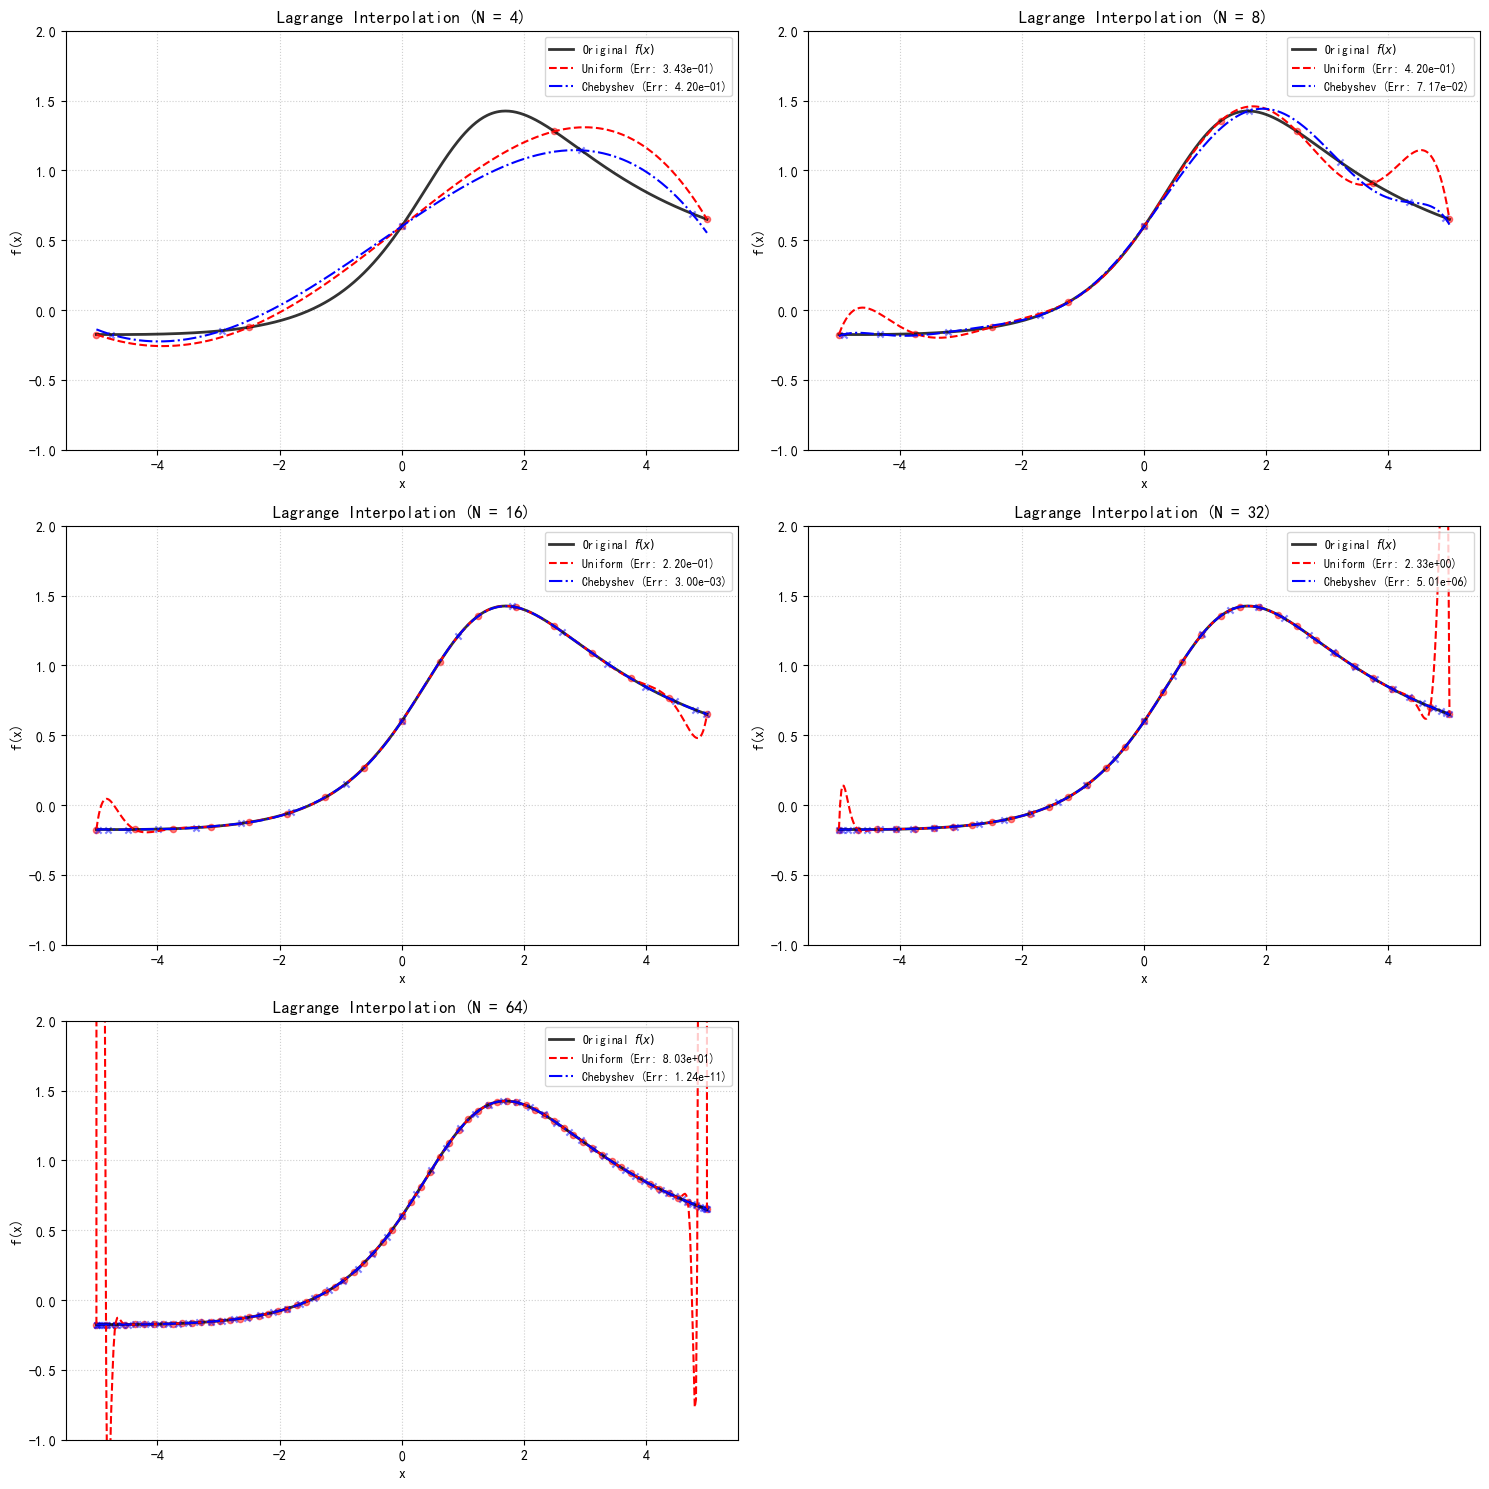

In [6]:
# 绘制插值曲线对比图

def plot_interpolation_comparison(
    results: list[InterpolationResult], 
    x_grid: np.ndarray, 
    y_true: np.ndarray
) -> None:
    """绘制不同 N 情况下的插值对比图."""
    unique_n = sorted(list(set(r.n for r in results)))
    n_count = len(unique_n)
    
    # 计算行数和列数，每行显示 2 个图
    cols = 2
    rows = (n_count + 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten() # 展平以便索引
    
    for i, n in enumerate(unique_n):
        ax = axes[i]
        ax.plot(x_grid, y_true, 'k-', label='Original $f(x)$', alpha=0.8, linewidth=2)
        
        # 均匀节点结果
        r_u = next(r for r in results if r.n == n and r.node_type == "Uniform")
        ax.plot(x_grid, r_u.y_interp, 'r--', label=f'Uniform (Err: {r_u.max_error:.2e})')
        ax.scatter(r_u.x_nodes, r_u.y_nodes, color='red', s=20, alpha=0.5)
        
        # Chebyshev 节点结果
        r_c = next(r for r in results if r.n == n and r.node_type == "Chebyshev")
        ax.plot(x_grid, r_c.y_interp, 'b-.', label=f'Chebyshev (Err: {r_c.max_error:.2e})')
        ax.scatter(r_c.x_nodes, r_c.y_nodes, color='blue', s=20, marker='x', alpha=0.5)
        
        ax.set_title(f'Lagrange Interpolation (N = {n})')
        ax.set_ylim([-1, 2]) # 限制 Y 轴范围以看清函数主体
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper right', fontsize='small')
        ax.set_ylabel('f(x)')
        ax.set_xlabel('x')
        
    # 隐藏多余的子图
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

plot_interpolation_comparison(exp_results, test_grid, f_true_vals)



---

## 四. 算法分析与实验总结

### 1. 算法分析

1. **均匀节点的精度与稳定性 (Runge 现象)**：
   - 实验结果显示，对于目标函数 $f(x) = \frac{2x+3}{x^2-2x+5}$，使用均匀节点进行插值时，增加插值次数 $N$ 反而导致了精度的剧烈恶化。
   - 当 $N=32$ 时，最大误差已达到 $2.33 \times 10^{0}$；而当 $N=64$ 时，误差剧增至 $8.03 \times 10^{1}$。
   - 在对比图中可以清晰观察到，随着 $N$ 的增大，均匀节点下的插值多项式在区间的两个边缘 $[-5, -4]$ 和 $[4, 5]$ 产生了剧烈的振荡。这种由于节点分布不当导致的高次多项式在边缘处发散的现象即为典型的 **Runge 现象**。

2. **Chebyshev 节点的性能优化**：
   - 与均匀节点形成鲜明对比，使用 Chebyshev 节点时，插值误差随 $N$ 的增加呈指数级下降。
   - 当 $N=64$ 时，最大误差仅为 $1.24 \times 10^{-11}$。这说明 Chebyshev 节点有效地抑制了 Runge 现象。
   - **理论解析**：Chebyshev 节点 $x_i$ 在区间边缘分布更密，在中间较稀。这种分布策略能够平衡 Lagrange 基函数在边缘处的极大值，使得插值余项在整个区间内更加平滑，从而实现了最优的逼近效果。

3. **数值实现细节——Lagrange 基函数法**：
   - 本次实验采用了基础的 **Lagrange 基函数累加法**。实验证明，在双精度浮点数范围内，只要节点选取合理（如 Chebyshev 节点），即使使用标准定义法，在 $N=64$ 的规模下仍然能保持极高的计算精度且数值稳定。

### 2. 实验总结

- 实验验证了在高次插值中，节点的物理分布比增加采样点数量更为关键。等距采样在处理复杂函数时易引发严重的 Runge 现象，导致结果不可靠。
- **Chebyshev 节点分布** 在处理插值边缘振荡方面是极佳的性能优化选型，显著提升了算法的收敛速度与数值稳定性。
- 在后续的数值逼近任务中，针对波动剧烈的目标函数，应优先考虑非均匀采样策略或引入**重心插值公式**以增强抗干扰能力。

